## Imports

In [ ]:
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from lime import lime_tabular
import lightning as L
import torch
import torch.nn as nn
import torchmetrics
from lightning.pytorch.callbacks import Callback
from torchmetrics.functional import recall
from pnpl.datasets import LibriBrainSpeech
from torch.utils.data import DataLoader
import lime_explanation
import lime_visualization
from models import SpeechClassifier, SpeechModel

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Load model

In [ ]:
# Set a fixed seed for reproducibility (just in case)
L.seed_everything(42)

checkpoint_path = "speech_model.ckpt"

# Load the SpeechClassifier model from checkpoint
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]
model = SpeechClassifier(
    checkpoint_path=checkpoint_path,
    input_dim=len(SENSORS_SPEECH_MASK),
    model_dim=100,
    learning_rate=1e-3,
    dropout_rate=0.5,
    lstm_layers=2,
    weight_decay=0.01,
    batch_norm=False,
    bi_directional=False
)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Load data

In [ ]:
# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
num_workers = 0

In [ ]:
# For training, we'll use all sessions from Sherlock 1 to Sherlock 5
train_run_keys = [("0",str(i),f"Sherlock{j}","1") for i in range(1,3)]
train_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys = train_run_keys,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=num_workers)

## Filter data

In [ ]:
# These are the sensors we identified as being particularly useful
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]

class FilteredDataset(torch.utils.data.Dataset):
    """
    Parameters:
        dataset: LibriBrain dataset.
        limit_samples (int, optional): If provided, limits the length of the dataset to this
                          number of samples.
        speech_silence_only (bool, optional): If True, only includes segments that are either
                          purely speech or purely silence (with additional balancing).
        apply_sensors_speech_mask (bool, optional): If True, applies a fixed sensor mask to the sensor
                          data in each sample.
    """
    def __init__(self,
                 dataset,
                 limit_samples=None,
                 disable=False,
                 apply_sensors_speech_mask=True):
        self.dataset = dataset
        self.limit_samples = limit_samples
        self.apply_sensors_speech_mask = apply_sensors_speech_mask

        # These are the sensors we identified:
        self.sensors_speech_mask = SENSORS_SPEECH_MASK

        self.balanced_indices = list(range(len(dataset.samples)))
        # Shuffle the indices
        self.balanced_indices = random.sample(self.balanced_indices, len(self.balanced_indices))

    def __len__(self):
        """Returns the number of samples in the filtered dataset."""
        if self.limit_samples is not None:
            return self.limit_samples
        return len(self.balanced_indices)

    def __getitem__(self, index):
        # Map index to the original dataset using balanced indices
        original_idx = self.balanced_indices[index]
        if self.apply_sensors_speech_mask:
            sensors = self.dataset[original_idx][0][self.sensors_speech_mask]
        else:
            sensors = self.dataset[original_idx][0][:]
        label_from_the_middle_idx = self.dataset[original_idx][1].shape[0] // 2
        return [sensors, self.dataset[original_idx][1][label_from_the_middle_idx]]

train_data_filtered = FilteredDataset(train_data)
train_loader_filtered = DataLoader(train_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

## Run LIME for multiple instances of speech and silence

In [58]:
# run lime for speech only
model.eval()
speech_cntr = 0
silence_cntr = 0

# lime hyperparams
perturb_function = lime_explanation.perturb_mean
num_slices = 40
num_perturbations = 150
kernel_width = 0.25
number_of_top_features = 5
important_segment_indices_speech = []
total_signal_speech = np.zeros((50, 23, 200))
important_segment_indices_silence = []
total_signal_silence = np.zeros((50, 23, 200))

for batch_idx, (curr_batch_inputs, curr_batch_labels) in enumerate(iter(train_loader_filtered)):
    if speech_cntr >= 50 and silence_cntr >= 50:
        break

    print(f"Running LIME for batch {batch_idx+1}... # Speech: {speech_cntr} | # Silence: {silence_cntr}")
    for curr_input, curr_label in zip(curr_batch_inputs, curr_batch_labels):
        if (curr_label == 1 and speech_cntr >= 50 and silence_cntr < 50) or (curr_label == 0 and speech_cntr < 0 and silence_cntr >= 50):
            continue

        seq = curr_input.detach().numpy()
        
        # segment signal
        slice_width = lime_explanation.segment_ecg_signal(seq, num_slices)

        # generate perturbations
        random_perturbations = lime_explanation.generate_random_perturbations(num_perturbations, num_slices)

        # apply perturbations -- calc class probabilities
        perturbation_predictions = lime_explanation.predict_perturbations(model, seq, random_perturbations, num_slices, perturb_function)

        # calc cosine distances and compute weights
        cosine_distances = lime_explanation.calculate_cosine_distances(random_perturbations, num_slices)
        weights = lime_explanation.calculate_weights_from_distances(cosine_distances, kernel_width)

        # train interpretable model
        segment_importance_coefficients = lime_explanation.fit_explainable_model(perturbation_predictions, random_perturbations, weights, target_class=1)

        # identify most important features
        top_influential_segments = lime_explanation.identify_top_influential_segments(segment_importance_coefficients, number_of_top_features)

        if curr_label == 1:
            total_signal_speech[speech_cntr, :, :] = seq
            important_segment_indices_speech.extend(top_influential_segments)
            speech_cntr += 1
        else:
            total_signal_silence[silence_cntr, :, :] = seq
            important_segment_indices_silence.extend(top_influential_segments)
            silence_cntr += 1
        
        if speech_cntr >= 50 and silence_cntr >= 50:
            break

important_segment_indices_speech = np.array(important_segment_indices_speech).flatten()
important_segment_indices_silence = np.array(important_segment_indices_silence).flatten()

Running LIME for batch 1... # Speech: 0 | # Silence: 0
Running LIME for batch 2... # Speech: 23 | # Silence: 9
Running LIME for batch 3... # Speech: 50 | # Silence: 12
Running LIME for batch 4... # Speech: 50 | # Silence: 16


KeyboardInterrupt: 

## Visualize most important features for speech

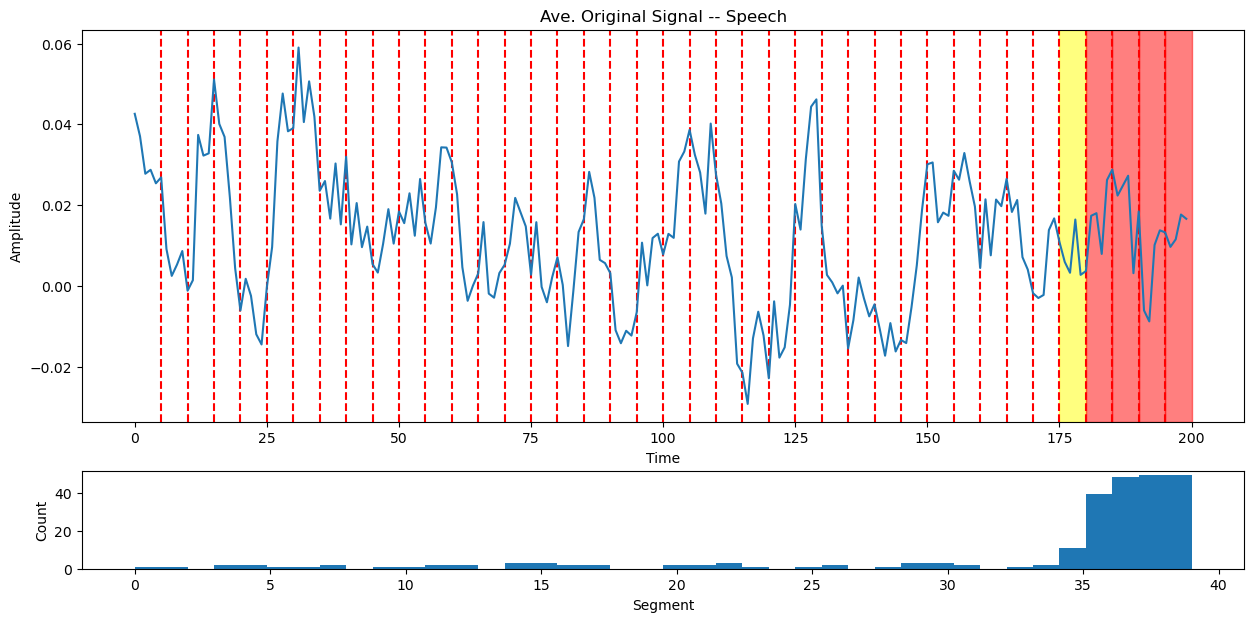

In [ ]:
ave_total_signal = total_signal_speech.mean(axis=0).mean(axis=0)
n_samples = ave_total_signal.shape[-1]

counts, bins = np.histogram(important_segment_indices_speech,bins=num_slices)
def get_color(count, total_n):
    if count <= int(total_n*0.1):
        return "grey" # 10%
    elif count <= int(total_n*0.25):
        return "yellow" # 25%
    elif count <= int(total_n*0.5):
        return "orange" # 50%
    else:
        return "red" # >50%
seg_colors = [get_color(count, 50) for count in counts]

fig,axes = plt.subplots(2,1,figsize=(15, 7),height_ratios=(4,1))

for i in range(1, num_slices):
    axes[0].axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')

axes[0].plot(ave_total_signal, label='Original ECG Signal')
for seg_idx,seg_color in zip(range(num_slices),seg_colors):
    if seg_color == "grey":
        continue
    start_idx = seg_idx * (n_samples // num_slices)
    end_idx = start_idx + (n_samples // num_slices)
    axes[0].axvspan(start_idx, end_idx, color=seg_color, alpha=0.5)  # Highlight influential segments

axes[0].set_title('Ave. Original Signal -- Speech')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')

axes[1].hist(important_segment_indices_speech,bins=num_slices)
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Count")

plt.show()

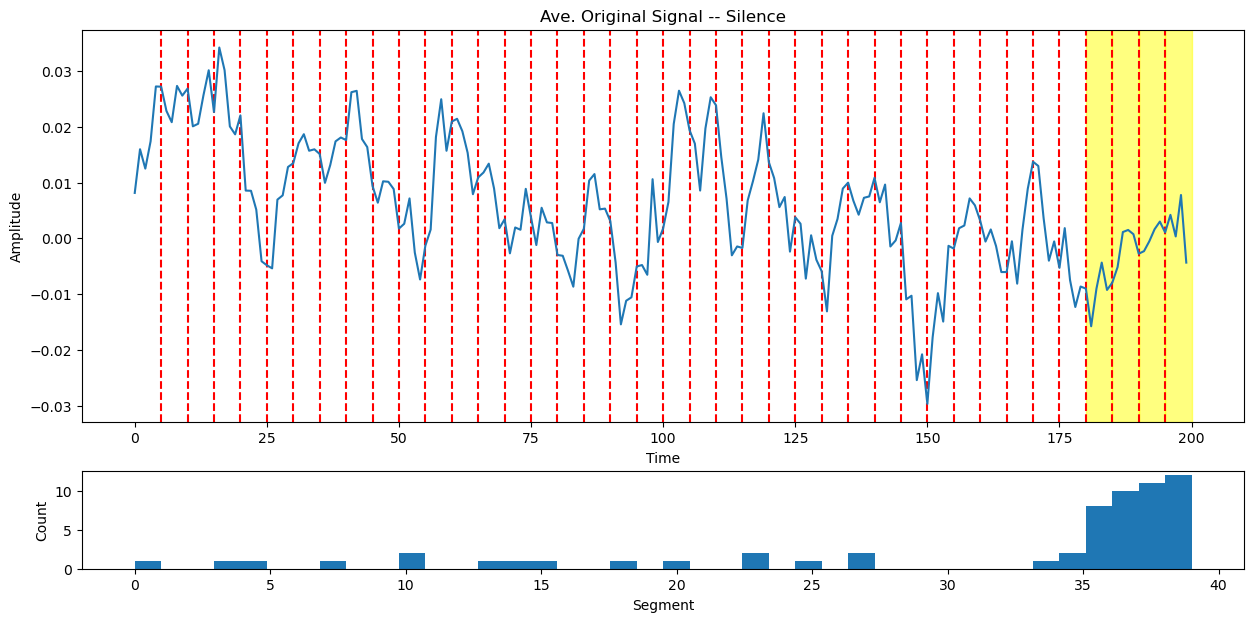

In [ ]:
ave_total_signal = total_signal_silence.mean(axis=0).mean(axis=0)
n_samples = ave_total_signal.shape[-1]

counts, bins = np.histogram(important_segment_indices_silence,bins=num_slices)
def get_color(count, total_n):
    if count <= int(total_n*0.1):
        return "grey"
    elif count <= int(total_n*0.25):
        return "yellow"
    elif count <= int(total_n*0.5):
        return "orange"
    else:
        return "red"
seg_colors = [get_color(count, 50) for count in counts]


fig,axes = plt.subplots(2,1,figsize=(15, 7),height_ratios=(4,1))

for i in range(1, num_slices):
    axes[0].axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')

axes[0].plot(ave_total_signal, label='Original ECG Signal')
for seg_idx,seg_color in zip(range(num_slices),seg_colors):
    if seg_color == "grey":
        continue
    start_idx = seg_idx * (n_samples // num_slices)
    end_idx = start_idx + (n_samples // num_slices)
    axes[0].axvspan(start_idx, end_idx, color=seg_color, alpha=0.5)  # Highlight influential segments

axes[0].set_title('Ave. Original Signal -- Silence')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')

axes[1].hist(important_segment_indices_silence,bins=num_slices)
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Count")

plt.show()